In [15]:
import os, re, random, math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Allow GPU memory growth — prevents TF from grabbing all VRAM at once
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

TF: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
BASE_PATH   = "./processed"        # change this to your actual folder path
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
CLASSES     = ["AD", "CN", "MCI"]
NUM_CLASSES = 3
EPOCHS_P1   = 25
EPOCHS_P2   = 80

TRAIN_DIR = os.path.join(BASE_PATH, "train")
VAL_DIR   = os.path.join(BASE_PATH, "val")
TEST_DIR  = os.path.join(BASE_PATH, "test")
os.makedirs('./models', exist_ok=True)

In [17]:
def extract_subject_id(filename):
    m = re.match(r'ADNI_(\d+_S_\d+)', filename)
    return m.group(1) if m else filename

for split, d in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    counts = {c: len(os.listdir(os.path.join(d, c))) for c in CLASSES}
    print(f"{split}: {counts}")

train: {'AD': 9360, 'CN': 12240, 'MCI': 19920}
val: {'AD': 2220, 'CN': 2940, 'MCI': 4680}
test: {'AD': 2280, 'CN': 2940, 'MCI': 4620}


In [18]:
train_labels = []
for idx, cls in enumerate(CLASSES):
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    train_labels.extend([idx] * n)

cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=np.array(train_labels))
cw = cw ** 1.5
cw = cw / cw.mean()
class_weight_dict = {int(i): float(cw[i]) for i in range(len(cw))}
print("Class weights:", {CLASSES[i]: round(class_weight_dict[i], 3) for i in range(3)})

Class weights: {'AD': 1.507, 'CN': 1.008, 'MCI': 0.485}


In [19]:
preprocess = tf.keras.applications.efficientnet.preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.06,
    brightness_range=[0.85, 1.15],
    fill_mode='reflect'
)
plain_datagen = ImageDataGenerator(preprocessing_function=preprocess)

def make_gen(datagen, directory, shuffle=True):
    return datagen.flow_from_directory(
        directory, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        color_mode='rgb', class_mode='categorical',
        classes=CLASSES, shuffle=shuffle, seed=SEED
    )

train_gen = make_gen(train_datagen, TRAIN_DIR, shuffle=True)
val_gen   = make_gen(plain_datagen, VAL_DIR,   shuffle=False)
test_gen  = make_gen(plain_datagen, TEST_DIR,  shuffle=False)

steps_per_epoch = math.ceil(train_gen.samples / BATCH_SIZE)
print(f"Steps per epoch: {steps_per_epoch}")

Found 41520 images belonging to 3 classes.
Found 9840 images belonging to 3 classes.
Found 9840 images belonging to 3 classes.
Steps per epoch: 1298


In [20]:
class FocalLoss(keras.losses.Loss):
    def __init__(self, gamma=2.5, label_smoothing=0.05, **kwargs):
        super().__init__(**kwargs)
        self.gamma = float(gamma)
        self.label_smoothing = float(label_smoothing)

    def call(self, y_true, y_pred):
        n_cls = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_true = y_true * (1.0 - self.label_smoothing) + self.label_smoothing / n_cls
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        return tf.reduce_mean(tf.reduce_sum(tf.pow(1.0 - p_t, self.gamma) * ce, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update({"gamma": float(self.gamma), "label_smoothing": float(self.label_smoothing)})
        return config


class GeMPooling(layers.Layer):
    def __init__(self, p_init=3.0, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.p_init = float(p_init)
        self.eps = float(eps)

    def build(self, input_shape):
        self.p = self.add_weight(
            name='p', shape=(1,),
            initializer=tf.constant_initializer(self.p_init),
            trainable=True,
            constraint=keras.constraints.MinMaxNorm(min_value=1.0, max_value=6.0)
        )
        super().build(input_shape)

    def call(self, x):
        x = tf.clip_by_value(x, self.eps, tf.reduce_max(x) + self.eps)
        return tf.pow(tf.reduce_mean(tf.pow(x, self.p), axis=[1, 2]), 1.0 / self.p)

    def get_config(self):
        config = super().get_config()
        config.update({"p_init": float(self.p_init), "eps": float(self.eps)})
        return config


class StochasticDepth(layers.Layer):
    def __init__(self, drop_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.drop_rate = float(drop_rate)

    def call(self, x, training=None):
        if training and self.drop_rate > 0.0:
            keep_prob = 1.0 - self.drop_rate
            shape = (tf.shape(x)[0],) + (1,) * (len(x.shape) - 1)
            random_tensor = tf.floor(tf.random.uniform(shape) + keep_prob)
            return x * random_tensor / keep_prob
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"drop_rate": float(self.drop_rate)})
        return config

In [21]:
def spatial_pyramid_pool(feat_map):
    gem  = GeMPooling(p_init=3.0, name='gem_full')(feat_map)
    p4   = layers.GlobalAveragePooling2D(name='gap_half')(
               layers.AveragePooling2D((2,2), name='down_half')(feat_map))
    p2   = layers.GlobalAveragePooling2D(name='gap_qtr')(
               layers.AveragePooling2D((4,4), name='down_qtr')(feat_map))
    return layers.Concatenate(name='spp_concat')([gem, p4, p2])

def build_model(num_classes=3):
    base = EfficientNetB3(include_top=False, weights='imagenet',
                          input_shape=(*IMG_SIZE, 3))
    base.trainable = False

    inp = keras.Input(shape=(*IMG_SIZE, 3))
    x   = base(inp, training=False)
    x   = spatial_pyramid_pool(x)
    x   = layers.GaussianNoise(0.02)(x)

    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.40)(x)
    x = StochasticDepth(drop_rate=0.10)(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.30)(x)
    x = StochasticDepth(drop_rate=0.05)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out), base

model, base_model = build_model()
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 efficientnetb3 (Functional)    (None, 7, 7, 1536)   10783535    ['input_4[0][0]']                
                                                                                                  
 down_half (AveragePooling2D)   (None, 3, 3, 1536)   0           ['efficientnetb3[0][0]']         
                                                                                                  
 down_qtr (AveragePooling2D)    (None, 1, 1, 1536)   0           ['efficientnetb3[0][0]']   

In [22]:
class CosineAnnealingLR(callbacks.Callback):
    def __init__(self, lr_max, lr_min, total_epochs, warmup=2):
        super().__init__()
        self.lr_max = float(lr_max)
        self.lr_min = float(lr_min)
        self.total_epochs = int(total_epochs)
        self.warmup = int(warmup)

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup:
            lr = self.lr_min + (self.lr_max - self.lr_min) * epoch / max(self.warmup, 1)
        else:
            prog = (epoch - self.warmup) / max(self.total_epochs - self.warmup, 1)
            lr = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (1 + math.cos(math.pi * prog))
        keras.backend.set_value(self.model.optimizer.learning_rate, float(lr))
        print(f"  LR = {lr:.3e}")

def get_callbacks(tag, phase, patience):
    return [
        callbacks.EarlyStopping('val_loss', patience=patience,
                                restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(f'./models/best_{tag}_p{phase}.h5',
                                  monitor='val_accuracy', save_best_only=True,
                                  save_weights_only=True, verbose=1),
        callbacks.ReduceLROnPlateau('val_loss', factor=0.5, patience=5,
                                    min_lr=1e-9, verbose=1),
    ]

loss_fn = FocalLoss(gamma=2.5, label_smoothing=0.05)

In [23]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss=loss_fn, metrics=['accuracy']
)

h1 = model.fit(
    train_gen, steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_P1, validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('effnet', 1, patience=8) + [
        CosineAnnealingLR(1e-3, 1e-5, EPOCHS_P1, warmup=3)],
    verbose=1
)
# Unfreeze top 60% of backbone, keep all BN frozen
total = len(base_model.layers)
for layer in base_model.layers[:int(total * 0.4)]:
    layer.trainable = False
for layer in base_model.layers[int(total * 0.4):]:
    layer.trainable = True
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-5, clipnorm=0.5),
    loss=loss_fn, metrics=['accuracy']
)

h2 = model.fit(
    train_gen, steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_P2, validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('effnet', 2, patience=18) + [
        CosineAnnealingLR(3e-5, 1e-8, EPOCHS_P2, warmup=2)],
    verbose=1
)
MC_PASSES = 25
all_mc = []

for i in range(MC_PASSES):
    test_gen.reset()
    preds = model.predict(test_gen, verbose=0)
    all_mc.append(preds)
    print(f"  Pass {i+1}/{MC_PASSES}", end="\r")

all_mc   = np.array(all_mc)
mc_probs = all_mc.mean(axis=0)
mc_var   = all_mc.var(axis=0)

y_true_img   = test_gen.classes
y_pred_image = np.argmax(mc_probs, axis=1)
acc_image    = np.mean(y_pred_image == y_true_img)
print(f"\nPer-IMAGE accuracy: {acc_image*100:.2f}%")

# Subject-level soft voting
img_meta = []
for cls_idx, cls in enumerate(CLASSES):
    for f in sorted(os.listdir(os.path.join(TEST_DIR, cls))):
        img_meta.append({'file': f, 'cls': cls_idx, 'subject': extract_subject_id(f)})

assert len(img_meta) == len(mc_probs), "Mismatch — check test_gen is not shuffled"

subject_probs  = defaultdict(lambda: np.zeros(NUM_CLASSES))
subject_labels = {}
subject_counts = defaultdict(int)

for i, meta in enumerate(img_meta):
    sid = meta['subject']
    subject_probs[sid]  += mc_probs[i]
    subject_labels[sid]  = meta['cls']
    subject_counts[sid] += 1

subject_ids = list(subject_probs.keys())
y_subj_pred = np.array([np.argmax(subject_probs[s]) for s in subject_ids])
y_subj_true = np.array([subject_labels[s]           for s in subject_ids])
acc_subject = np.mean(y_subj_pred == y_subj_true)

print(f"Per-SUBJECT accuracy: {acc_subject*100:.2f}%  ← headline number")
print("\nPer-class breakdown:")
for i, cls in enumerate(CLASSES):
    mask = y_subj_true == i
    if mask.sum() > 0:
        ca = np.mean(y_subj_pred[mask] == y_subj_true[mask])
        print(f"  {cls}: {ca*100:.2f}%  ({mask.sum()} subjects)")

print("\n" + classification_report(y_subj_true, y_subj_pred, target_names=CLASSES))

  LR = 1.000e-05
Epoch 1/25
1298/1298 [==============================] - ETA: 0s - loss: 0.6932 - accuracy: 0.3658
Epoch 1: val_accuracy improved from -inf to 0.37825, saving model to ./models\best_effnet_p1.h5
1298/1298 [==============================] - 571s 203ms/step - loss: 0.6932 - accuracy: 0.3658 - val_loss: 0.5519 - val_accuracy: 0.3783 - lr: 1.0000e-05
  LR = 3.400e-04
Epoch 2/25
1298/1298 [==============================] - ETA: 0s - loss: 0.5180 - accuracy: 0.4388
Epoch 2: val_accuracy improved from 0.37825 to 0.49350, saving model to ./models\best_effnet_p1.h5
1298/1298 [==============================] - 265s 204ms/step - loss: 0.5180 - accuracy: 0.4388 - val_loss: 0.4795 - val_accuracy: 0.4935 - lr: 3.4000e-04
  LR = 6.700e-04
Epoch 3/25
1298/1298 [==============================] - ETA: 0s - loss: 0.4125 - accuracy: 0.4744
Epoch 3: val_accuracy did not improve from 0.49350
1298/1298 [==============================] - 263s 203ms/step - loss: 0.4125 - accuracy: 0.4744 - val_

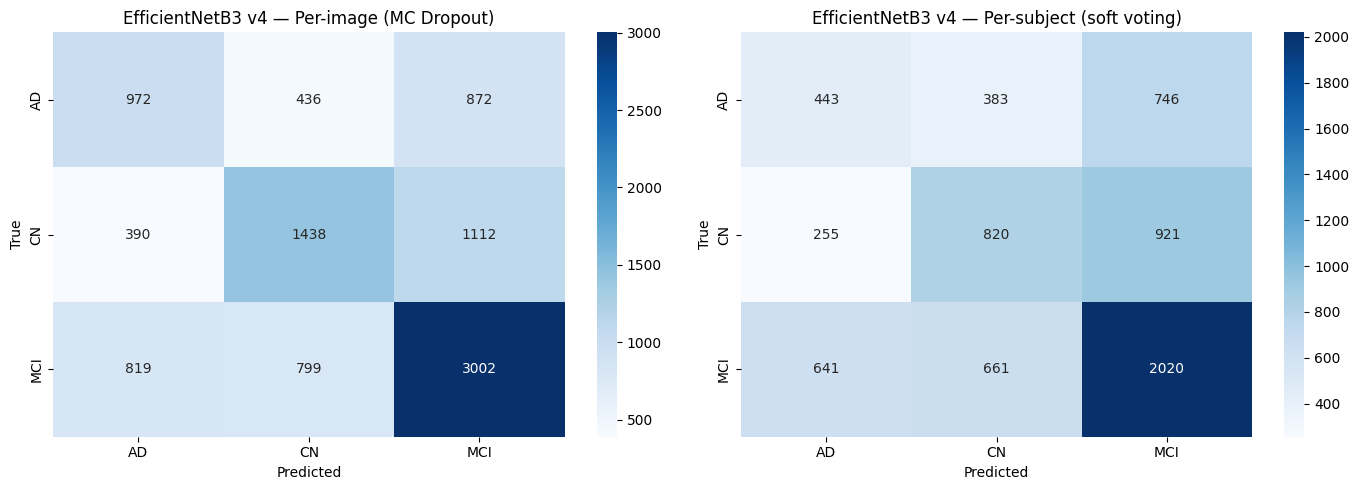

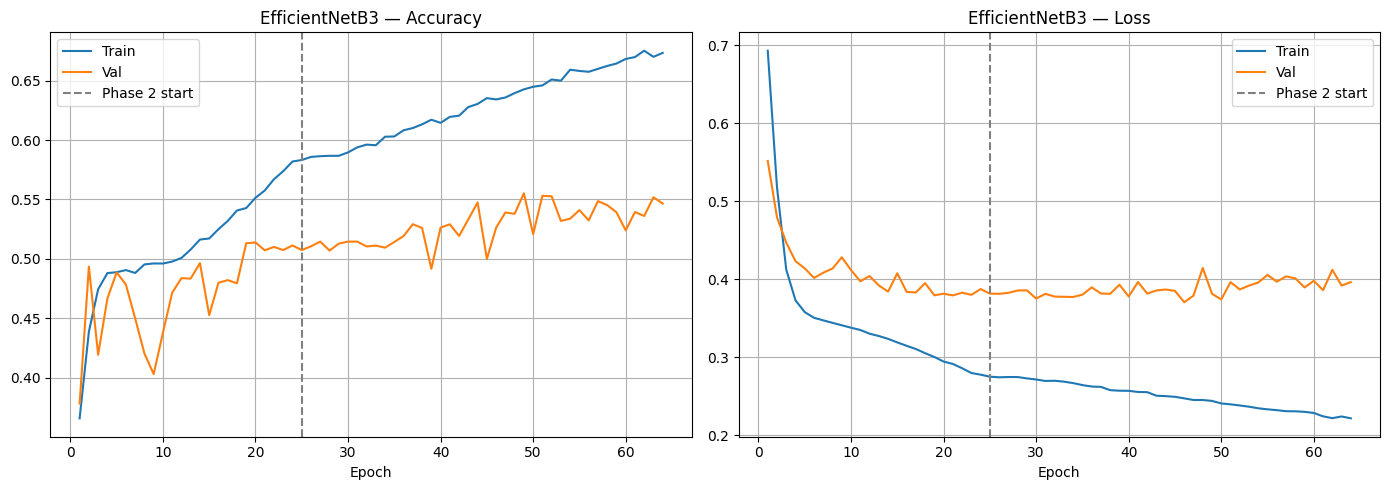

In [24]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm_data, title in zip(axes,
    [confusion_matrix(y_true_img, y_pred_image),
     confusion_matrix(y_subj_true, y_subj_pred)],
    ['Per-image (MC Dropout)', 'Per-subject (soft voting)']):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title(f'EfficientNetB3 v4 — {title}')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('./models/confusion_matrices.png', dpi=150)
plt.show()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
p1_end   = len(h1.history['accuracy'])
ep_total = range(1, p1_end + len(h2.history['accuracy']) + 1)
combined = lambda k: h1.history[k] + h2.history[k]

for ax, m, title in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(ep_total, combined(m),          label='Train')
    ax.plot(ep_total, combined(f'val_{m}'), label='Val')
    ax.axvline(p1_end, color='gray', linestyle='--', label='Phase 2 start')
    ax.set_title(f'EfficientNetB3 — {title}')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('./models/training_curves.png', dpi=150)
plt.show()